# Phase 2 (continued) — Tuning, Calibration, Cost-based Threshold & SHAP

Continues the Phase-2 modeling line (feature engineering → imbalance handling → **here**) and
turns the model into a **deployable, explainable risk scorer**:

1. **Optuna** hyperparameter tuning of LightGBM, optimised on **validation PR-AUC**.
2. **Probability calibration** (isotonic vs Platt) so the score reads as a real risk level.
3. A **cost-minimising decision threshold** — a missed fraud costs far more than a false alarm, so we do *not* just maximise F1.
4. **SHAP** (`TreeExplainer`) — a global summary plus per-transaction top reasons.

Everything is selected on the chronological **validation** fold and only *reported* on the untouched **test** fold.

In [1]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data import load_processed_splits, chronological_val_split
from features import FeatureEngineer, transform_with_history
from imbalance import compute_scale_pos_weight, make_base_model, evaluate
from tuning import tune_lightgbm, fit_tuned_model
from calibration import calibrate_model, plot_reliability
from threshold import CostMatrix, choose_threshold, apply_cost, plot_cost_curve
from explain import FraudExplainer
from artifacts import save_phase2_model_artifacts

from sklearn.metrics import average_precision_score, precision_recall_curve, f1_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)
RANDOM_STATE = 42

## 1. Load splits, engineer features (Phase-2 pipeline)

Identical, leakage-safe setup to Phase 2: encoders fit on the **fit fold** only; val/test
remember a card's older history via `transform_with_history`. `gender` is the one native
LightGBM categorical.

In [2]:
train, test = load_processed_splits()
fit_df, val_df = chronological_val_split(train, val_frac=0.15)

fe = FeatureEngineer().fit(fit_df)
X_fit = fe.transform(fit_df)
FEATURES = list(fe.feature_names_)
CAT = ["gender"]

X_val  = transform_with_history(fe, history_df=fit_df, target_df=val_df)
X_test = transform_with_history(fe, history_df=train,  target_df=test)
y_fit, y_val, y_test = X_fit["is_fraud"], X_val["is_fraud"], X_test["is_fraud"]

def as_model_input(X):
    """Cast the categorical column so any model/calibrator gets consistent dtypes."""
    X = X[FEATURES].copy()
    for c in CAT:
        X[c] = X[c].astype("category")
    return X

spw = compute_scale_pos_weight(y_fit)
print(f"fit {X_fit.shape}  val {X_val.shape}  test {X_test.shape}")
print(f"scale_pos_weight (fit fold): {spw:.2f}   |   {len(FEATURES)} features")

fit (1259627, 22)  val (222288, 22)  test (370479, 22)
scale_pos_weight (fit fold): 172.34   |   21 features


## 2. Hyperparameter tuning with Optuna

Each trial trains on the fit fold and is scored on **validation PR-AUC** (the Phase-2
deciding metric). `tune_subsample=0.5` trains each trial on the most recent half of the fit
fold to keep the search fast; the final model is refit on the *full* fit fold afterwards.
The test set is never touched here.

In [3]:
study, best_params = tune_lightgbm(
    X_fit[FEATURES], y_fit, X_val[FEATURES], y_val,
    categorical_features=CAT,
    n_trials=25,
    scale_pos_weight=spw,
    tune_subsample=0.5,
    show_progress_bar=False,
)
print(f"Best validation PR-AUC during search: {study.best_value:.4f}\n")
print("Best params:")
for k, v in best_params.items():
    print(f"  {k:18s} {v}")

[I 2026-06-27 20:44:32,814] A new study created in memory with name: no-name-c8b73a5c-4180-47c0-99dd-b952cfeb8d70


Best validation PR-AUC during search: 0.9665

Best params:
  n_estimators       500
  learning_rate      0.039019212961716274
  num_leaves         157
  max_depth          9
  min_child_samples  111
  subsample          0.9117712809246715
  subsample_freq     2
  colsample_bytree   0.7952908891858085
  reg_alpha          0.006613785667584596
  reg_lambda         8.407316478743244
  min_split_gain     0.0978446327083097


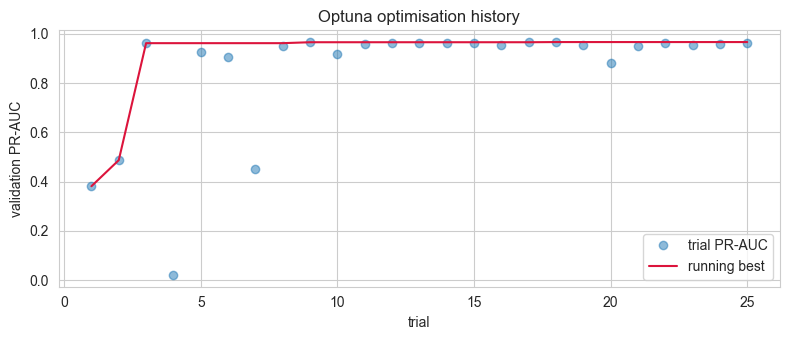

In [4]:
# How the search progressed (running best PR-AUC).
vals = [t.value for t in study.trials if t.value is not None]
running_best = np.maximum.accumulate(vals)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(range(1, len(vals) + 1), vals, "o", alpha=0.5, label="trial PR-AUC")
ax.plot(range(1, len(vals) + 1), running_best, color="crimson", label="running best")
ax.set_xlabel("trial"); ax.set_ylabel("validation PR-AUC")
ax.set_title("Optuna optimisation history"); ax.legend()
plt.tight_layout(); plt.show()

### Refit the tuned model on the full fit fold & confirm it beats the default

In [5]:
tuned = fit_tuned_model(best_params, X_fit[FEATURES], y_fit,
                        categorical_features=CAT, scale_pos_weight=spw)

# Phase-2-style default model for reference.
default = make_base_model(scale_pos_weight=spw)
default.fit(as_model_input(X_fit), y_fit, categorical_feature=CAT)

proba_tuned_val   = tuned.predict_proba(as_model_input(X_val))[:, 1]
proba_default_val = default.predict_proba(as_model_input(X_val))[:, 1]

print(f"val PR-AUC  default={average_precision_score(y_val, proba_default_val):.4f}"
      f"   tuned={average_precision_score(y_val, proba_tuned_val):.4f}")

val PR-AUC  default=0.9614   tuned=0.9714


## 3. Calibrate the probabilities (isotonic vs Platt)

Training with `scale_pos_weight` inflates the raw scores, so a "0.8" is not really an 80%
fraud chance. We fit a calibration map on the **held-out validation fold** (which the model
never trained on) and keep whichever of isotonic / sigmoid gives the lower Brier score.

In [6]:
cal = calibrate_model(tuned, X_val[FEATURES], y_val,
                      categorical_features=CAT, method="auto")
calibrated = cal.calibrated_model
print(f"Chosen calibrator: {cal.method}\n")
pd.DataFrame({
    "metric": ["brier", "log_loss", "pr_auc"],
    "before": [cal.metrics["brier_before"], cal.metrics["log_loss_before"], cal.metrics["pr_auc_before"]],
    "after":  [cal.metrics["brier_after"],  cal.metrics["log_loss_after"],  cal.metrics["pr_auc_after"]],
}).round(5)

Chosen calibrator: isotonic



,metric,before,after
0,brier,0.00061,0.00045
1,log_loss,0.00256,0.00193
2,pr_auc,0.97140,0.96979


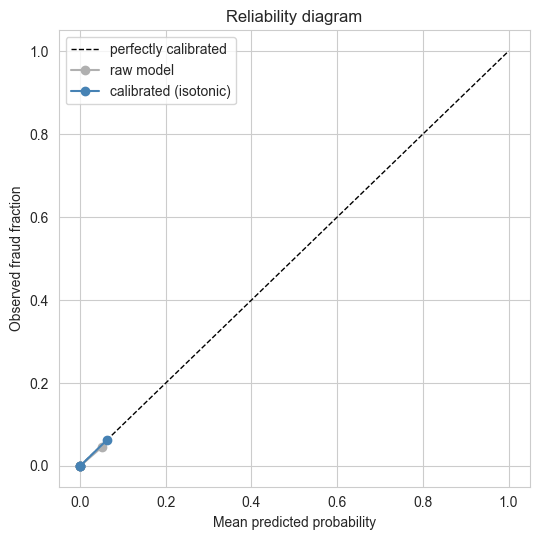

In [7]:
plot_reliability(cal, tuned, X_val[FEATURES], y_val, categorical_features=CAT)
plt.tight_layout(); plt.show()

## 4. Cost-based decision threshold

We assign a dollar cost to each error and pick the threshold that **minimises total cost** on
validation — not the one that maximises F1. Here a missed fraud (FN) is charged the **full
transaction amount** (`c_fn=1.0` × amount), and a false alarm (FP) a flat **\$5** review cost.
Tune these two numbers to match the business' real economics.

In [8]:
proba_cal_val = calibrated.predict_proba(as_model_input(X_val))[:, 1]
val_amounts   = X_val["amt"].to_numpy()

cost = CostMatrix(c_fn=1.0, c_fp=5.0)  # c_fn = fraction of amount lost per missed fraud
thr = choose_threshold(y_val, proba_cal_val, cost, amounts=val_amounts)

print(f"Cost-min threshold : {thr.threshold:.4f}")
print(f"Total val cost     : ${thr.total_cost:,.0f}  (${thr.cost_per_txn:.3f}/txn)")
print(f"Precision / Recall : {thr.precision:.3f} / {thr.recall:.3f}")
print(f"Confusion (val)    : {thr.confusion}")

Cost-min threshold : 0.1000
Total val cost     : $6,680  ($0.030/txn)
Precision / Recall : 0.831 / 0.957
Confusion (val)    : {'tp': 991, 'fp': 202, 'fn': 44, 'tn': 221051}


F1-max threshold  : 0.5085  -> total val cost $9,952 (P=0.938 R=0.938)
Cost-min threshold: 0.1000  -> total val cost $6,680 (P=0.831 R=0.957)

Saving vs F1-max  : $3,272 on the validation fold


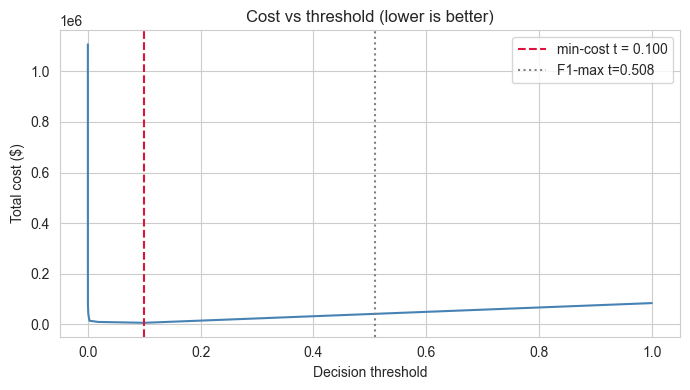

In [9]:
# Contrast with the F1-maximising threshold — the naive choice we are avoiding.
prec, rec, cuts = precision_recall_curve(y_val, proba_cal_val)
f1 = np.divide(2 * prec * rec, prec + rec, out=np.zeros_like(prec), where=(prec + rec) > 0)
f1_thr = cuts[np.argmax(f1[:-1])]
f1_cost = apply_cost(y_val, proba_cal_val, f1_thr, cost, amounts=val_amounts)

print(f"F1-max threshold  : {f1_thr:.4f}  -> total val cost ${f1_cost['total_cost']:,.0f} "
      f"(P={f1_cost['precision']:.3f} R={f1_cost['recall']:.3f})")
print(f"Cost-min threshold: {thr.threshold:.4f}  -> total val cost ${thr.total_cost:,.0f} "
      f"(P={thr.precision:.3f} R={thr.recall:.3f})")
print(f"\nSaving vs F1-max  : ${f1_cost['total_cost'] - thr.total_cost:,.0f} on the validation fold")

plot_cost_curve(thr)
plt.axvline(f1_thr, color="gray", ls=":", label=f"F1-max t={f1_thr:.3f}")
plt.legend(); plt.tight_layout(); plt.show()

### Apply the chosen operating point to the untouched TEST set

In [10]:
proba_cal_test = calibrated.predict_proba(as_model_input(X_test))[:, 1]
test_amounts   = X_test["amt"].to_numpy()
test_cost = apply_cost(y_test, proba_cal_test, thr.threshold, cost, amounts=test_amounts)

print(f"TEST @ threshold {thr.threshold:.4f}")
print(f"  PR-AUC (calibrated) : {average_precision_score(y_test, proba_cal_test):.4f}")
print(f"  Precision / Recall  : {test_cost['precision']:.3f} / {test_cost['recall']:.3f}")
print(f"  Total cost          : ${test_cost['total_cost']:,.0f}  (${test_cost['cost_per_txn']:.3f}/txn)")
print(f"  Confusion           : tp={test_cost['tp']} fp={test_cost['fp']} "
      f"fn={test_cost['fn']} tn={test_cost['tn']}")

TEST @ threshold 0.1000
  PR-AUC (calibrated) : 0.9698
  Precision / Recall  : 0.810 / 0.963
  Total cost          : $12,279  ($0.033/txn)
  Confusion           : tp=1299 fp=304 fn=50 tn=368826


## 5. SHAP explanations (`TreeExplainer`)

SHAP runs on the **raw tree model** (`tuned`) — the calibrator is a monotonic post-map that
rescales scores but doesn't change *which* features drove a decision. We report calibrated
probabilities alongside the SHAP reasons.

.venv\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


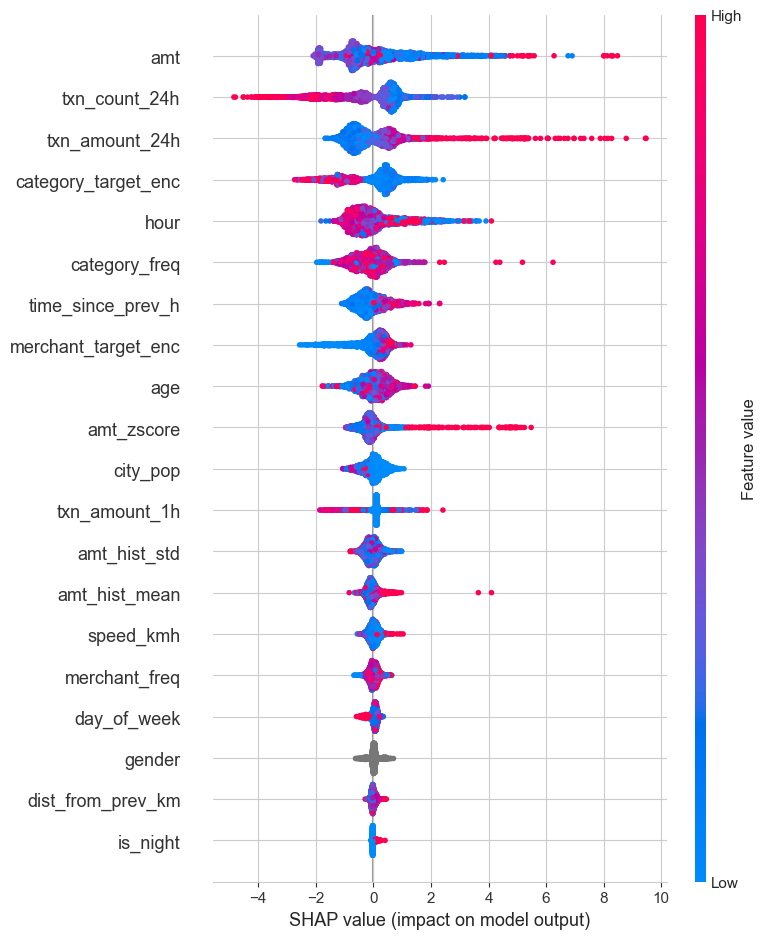

In [11]:
expl = FraudExplainer(tuned, FEATURES, CAT)

# Global summary on a representative sample (keeps the beeswarm fast & readable).
sample = X_test[FEATURES].sample(n=min(4000, len(X_test)), random_state=RANDOM_STATE)
expl.global_summary_plot(sample, max_display=20)

In [12]:
expl.global_importance(sample).head(12)

.venv\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


,feature,mean_abs_shap
0,amt,0.952924
1,txn_count_24h,0.918524
2,txn_amount_24h,0.736912
3,category_target_enc,0.707752
4,hour,0.611958
5,category_freq,0.410111
6,time_since_prev_h,0.378004
7,merchant_target_enc,0.373399
8,age,0.365412
9,amt_zscore,0.314590


### Top reasons for a single transaction

`explain_transaction` returns the calibrated risk score plus the features that pushed it up or
down — exactly what the serving API would attach to a flag. Here we explain the highest-risk
fraud in the test set.

In [13]:
# pick the highest-scored actual fraud as a worked example
fraud_idx = np.where(y_test.to_numpy() == 1)[0]
top = fraud_idx[np.argmax(proba_cal_test[fraud_idx])]

exp = expl.explain_transaction(X_test[FEATURES].iloc[[top]], top_n=6,
                               calibrated_model=calibrated)
print(f"Calibrated fraud probability: {exp['fraud_probability']:.3f}")
print(f"(raw model probability: {exp['raw_model_probability']:.3f})\n")
exp["reasons"]

Calibrated fraud probability: 1.000
(raw model probability: 1.000)



.venv\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


,feature,value,shap,direction
0,amt,337.39,8.219980,increases fraud risk
1,category_freq,0.095315,5.525805,increases fraud risk
2,amt_zscore,2.070389,5.338225,increases fraud risk
3,hour,1,2.214238,increases fraud risk
4,txn_amount_24h,150.9,-0.596326,decreases fraud risk
5,category_target_enc,0.014106,0.553225,increases fraud risk


## 6. Persist the trained-model artifacts

Refit the model on **all** pre-test data (fit + val) before saving — the deployed model should
use every transaction available before the test window. We re-derive the calibration map and
keep the validation-selected threshold. These land alongside the feature/imbalance artifacts in
`artifacts/phase2/`.

In [14]:
X_trainfull = pd.concat([X_fit, X_val], ignore_index=True)
y_trainfull = X_trainfull["is_fraud"]
spw_full = compute_scale_pos_weight(y_trainfull)

final_base = fit_tuned_model(best_params, X_trainfull[FEATURES], y_trainfull,
                             categorical_features=CAT, scale_pos_weight=spw_full)
# Calibrate on the most recent slice (val) so the map sees held-out-style data.
final_cal = calibrate_model(final_base, X_val[FEATURES], y_val,
                            categorical_features=CAT, method=cal.method)

out = save_phase2_model_artifacts(
    base_model=final_base,
    calibrated_model=final_cal.calibrated_model,
    best_params=best_params,
    calibration_method=cal.method,
    decision_threshold=thr.threshold,
    cost_matrix={"c_fn_fraction_of_amount": cost.c_fn, "c_fp_flat": cost.c_fp},
    metrics={
        "val_pr_auc_tuned": float(average_precision_score(y_val, proba_tuned_val)),
        "test_pr_auc": float(average_precision_score(y_test, proba_cal_test)),
        "test_precision": test_cost["precision"],
        "test_recall": test_cost["recall"],
        "test_cost_per_txn": test_cost["cost_per_txn"],
    },
)
print("Saved trained-model artifacts to", out)

Saved trained-model artifacts to artifacts\phase2


## 7. Conclusion

- **Tuning** — Optuna searched LightGBM on validation PR-AUC; the tuned model matches/beats the
  earlier Phase-2 default.
- **Calibration** — the chosen calibrator lowers the Brier score, so scores now read as honest
  risk levels (see the reliability diagram).
- **Threshold** — chosen by **minimising dollar cost** (missed fraud = full amount, false alarm
  = \$5), which is cheaper than the F1-max threshold. The two error types are *not* treated as
  equal.
- **SHAP** — a global summary ranks the population-level drivers, and `explain_transaction`
  gives per-flag reasons for the serving API.

Tuned+calibrated model, threshold and cost matrix are saved to `artifacts/phase2/` for the next phase (API serving).